In [196]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [197]:
PACKAGE_USED = 0  # 0 = sklearn; 1 = sktime; 2 = aeon

In [198]:
APPROACH = "rf"

In [199]:
CHANNEL_CONFIG = "g-a"

In [200]:
TRAIN_DIR = [
    R"dataset"
]

In [201]:
TEST_DIR = [
    R"dataset"
]

# Build DataFrame

In [202]:
def build_df(dirs):
    """
    dirs: list of directory paths containing CSV files
    """
    all_csv_files = []

    for _DIR in dirs:
        file_pattern = os.path.join(_DIR, "*.csv")
        csv_files = glob.glob(file_pattern)
        print(f"{_DIR} -> {len(csv_files)} CSV files found")
        all_csv_files.extend(csv_files)

    print(f"A total of {len(all_csv_files)} CSV files were used in constructing this DataFrame.")

    if not all_csv_files:
        raise ValueError("No CSV files found in the provided directories.")

    df = pd.concat((pd.read_csv(f) for f in all_csv_files), ignore_index=True)
    return df

In [203]:
df_train = build_df(TRAIN_DIR)

dataset -> 2 CSV files found
A total of 2 CSV files were used in constructing this DataFrame.


In [204]:
df_test = build_df(TEST_DIR)

dataset -> 2 CSV files found
A total of 2 CSV files were used in constructing this DataFrame.


In [205]:
print(df_train.duplicated().sum())

0


In [206]:
print(df_test.duplicated().sum())

0


In [207]:
df_train.drop_duplicates(inplace=True)

In [208]:
df_test.drop_duplicates(inplace=True)

## Remove unneeded columns

In [209]:
match CHANNEL_CONFIG:
    case "gyro":
        df_train = df_train.filter(regex=r'^(gyro|motion)')
        df_test = df_test.filter(regex=r'^(gyro|motion)')
    case "accel":
        df_train = df_train.filter(regex=r'^(acc|motion)')
        df_test = df_test.filter(regex=r'^(acc|motion)')
    case "mag":
        df_train = df_train.filter(regex=r'^(mag|motion)')
        df_test = df_test.filter(regex=r'^(mag|motion)')
    case "ahrs":
        df_train = df_train.filter(regex=r'^(ahrs|motion)')
        df_test = df_test.filter(regex=r'^(ahrs|motion)')
    case "g-a":
        df_train = df_train.filter(regex=r'^(gyro|acc|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|motion)')
    case "g-m":
        df_train = df_train.filter(regex=r'^(gyro|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|mag|motion)')
    case "a-m":
        df_train = df_train.filter(regex=r'^(acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(acc|mag|motion)')
    case "g-a-m":
        df_train = df_train.filter(regex=r'^(gyro|acc|mag|motion)')
        df_test = df_test.filter(regex=r'^(gyro|acc|mag|motion)')
    case _:
        pass

In [210]:
# df_train = df_train.drop(df_train[df_train["motion_type"] == "POUR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_UP"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "TILT_DOWN"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "STIR"].index)
# df_train = df_train.drop(df_train[df_train["motion_type"] == "ROLL"].index)


In [211]:
df_train.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_28,acc_y_28,acc_z_28,gyro_x_29,gyro_y_29,gyro_z_29,acc_x_29,acc_y_29,acc_z_29,motion_type
0,-0.102987,-0.093500,0.007975,0.004125,0.002612,0.047713,0.028050,0.116050,0.241450,2.68095,...,4.19700,4.19700,3.69405,-8.970000,-8.970000,-6.946950,-10.251000,-10.251000,-3.51795,HIT
1,0.150287,0.215463,0.215463,0.091163,0.085800,0.085800,-0.487987,-0.579562,-0.579562,1.57500,...,-0.82905,3.03300,3.03300,-15.576001,-12.097951,-12.097951,-5.203950,-6.273000,-6.27300,HIT
2,-0.095837,-0.154412,-0.235675,0.109175,0.064488,-0.010862,-0.153313,-0.145887,-0.182737,0.37995,...,-3.39195,0.96405,0.31500,-6.994051,-2.527950,-5.898000,-1.933050,-9.991950,-0.66300,HIT
3,0.902550,0.795712,0.762438,0.227700,0.241175,0.167887,0.331925,0.201438,0.062013,-0.08400,...,2.38695,2.38695,4.17600,-3.427950,-3.427950,-8.833950,-12.757951,-12.757951,-4.61295,HIT
4,-0.220275,-0.348425,-0.314600,0.150975,0.086763,0.080850,-0.233475,-0.276925,-0.239800,0.64800,...,3.28905,3.39495,1.94595,-9.460951,-8.556001,-6.063000,-5.959050,-1.245000,0.38205,HIT


In [212]:
df_test.head()

,gyro_x_0,gyro_y_0,gyro_z_0,acc_x_0,acc_y_0,acc_z_0,gyro_x_1,gyro_y_1,gyro_z_1,acc_x_1,...,acc_x_28,acc_y_28,acc_z_28,gyro_x_29,gyro_y_29,gyro_z_29,acc_x_29,acc_y_29,acc_z_29,motion_type
0,-0.102987,-0.093500,0.007975,0.004125,0.002612,0.047713,0.028050,0.116050,0.241450,2.68095,...,4.19700,4.19700,3.69405,-8.970000,-8.970000,-6.946950,-10.251000,-10.251000,-3.51795,HIT
1,0.150287,0.215463,0.215463,0.091163,0.085800,0.085800,-0.487987,-0.579562,-0.579562,1.57500,...,-0.82905,3.03300,3.03300,-15.576001,-12.097951,-12.097951,-5.203950,-6.273000,-6.27300,HIT
2,-0.095837,-0.154412,-0.235675,0.109175,0.064488,-0.010862,-0.153313,-0.145887,-0.182737,0.37995,...,-3.39195,0.96405,0.31500,-6.994051,-2.527950,-5.898000,-1.933050,-9.991950,-0.66300,HIT
3,0.902550,0.795712,0.762438,0.227700,0.241175,0.167887,0.331925,0.201438,0.062013,-0.08400,...,2.38695,2.38695,4.17600,-3.427950,-3.427950,-8.833950,-12.757951,-12.757951,-4.61295,HIT
4,-0.220275,-0.348425,-0.314600,0.150975,0.086763,0.080850,-0.233475,-0.276925,-0.239800,0.64800,...,3.28905,3.39495,1.94595,-9.460951,-8.556001,-6.063000,-5.959050,-1.245000,0.38205,HIT


<Axes: xlabel='motion_type', ylabel='count'>

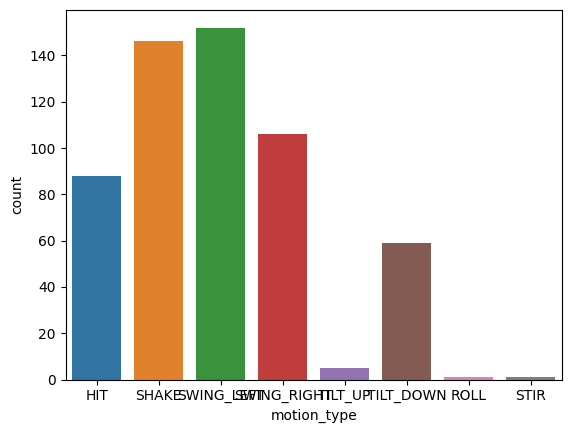

In [213]:
sns.countplot(df_train, x="motion_type", hue="motion_type")

In [214]:
len(df_train)

558

<Axes: xlabel='motion_type', ylabel='count'>

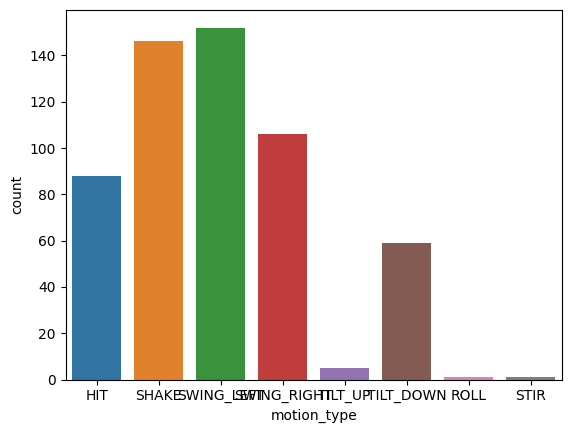

In [215]:
sns.countplot(df_test, x="motion_type", hue="motion_type")

In [216]:
len(df_test)

558

## Get X and y

In [217]:
from sklearn.preprocessing import LabelEncoder

In [218]:
def get_X_and_y(df: pd.DataFrame, package_used: int) -> tuple[np.array, np.array]:
    if package_used == 0:  # sklearn
        X = df.drop(columns=["motion_type"]).values
        y = df["motion_type"].values
        return X.astype("float32"), y
    
    elif package_used == 1:  # sktime
        X_df = df.drop(columns=["motion_type"])
        y = df["motion_type"].values
        
        n_timesteps = 30
        channels = []
        match CHANNEL_CONFIG:
            case "accel":
                channels = ["accel_x", "accel_y", "accel_z"]
            case "gyro":
                channels = ["gyro_x", "gyro_y", "gyro_z"]
            case "mag":
                channels = ["mag_x", "mag_y", "mag_z"]
            case "ahrs":
                channels = ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
            case "g-a":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"]
            case "g-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"]
            case "a-m":
                channels = ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case "g-a-m":
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"]
            case _:
                channels = ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z", "ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"]
        n_channels = len(channels)

        X = np.zeros((len(df), n_channels, n_timesteps))

        for t in range(n_timesteps):
            for c, channel in enumerate(channels):
                col_name = f"{channel}_{t}"
        
                X[:, c, t] = X_df[col_name].values
                
        return X.astype("float32"), y

    else:  # aeon
        y = df["motion_type"].values

        n_timesteps = 30

        channels = {
            "accel": ["accel_x", "accel_y", "accel_z"],
            "gyro": ["gyro_x", "gyro_y", "gyro_z"],
            "mag": ["mag_x", "mag_y", "mag_z"],
            "ahrs": ["ahrs_x", "ahrs_y", "ahrs_z", "ahrs_w"],
            "g-a": ["gyro_x", "gyro_y", "gyro_z", "accel_x", "accel_y", "accel_z"],
            "g-m": ["gyro_x", "gyro_y", "gyro_z", "mag_x", "mag_y", "mag_z"],
            "a-m": ["accel_x", "accel_y", "accel_z", "mag_x", "mag_y", "mag_z"],
            "g-a-m": ["gyro_x", "gyro_y", "gyro_z",
                    "accel_x", "accel_y", "accel_z",
                    "mag_x", "mag_y", "mag_z"],
        }.get(CHANNEL_CONFIG, [
            "gyro_x","gyro_y","gyro_z",
            "accel_x","accel_y","accel_z",
            "mag_x","mag_y","mag_z",
            "ahrs_x","ahrs_y","ahrs_z","ahrs_w"
        ])

        n_channels = len(channels)
        X = np.zeros((len(df), n_channels, n_timesteps), dtype="float32")

        for t in range(n_timesteps):
            for c, ch in enumerate(channels):
                X[:, c, t] = df[f"{ch}_{t}"].values

        return X.astype("float32"), y

In [219]:
X_train, y_train = get_X_and_y(df_train, PACKAGE_USED)
X_test, y_test = get_X_and_y(df_test, PACKAGE_USED)

In [220]:
X_train.shape

(558, 180)

In [221]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [222]:
le.classes_

array(['HIT', 'ROLL', 'SHAKE', 'STIR', 'SWING_LEFT', 'SWING_RIGHT',
       'TILT_DOWN', 'TILT_UP'], dtype=object)

In [223]:
from sktime.classification.kernel_based import RocketClassifier
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.classification.deep_learning import InceptionTimeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from aeon.classification.deep_learning import LITETimeClassifier

In [224]:
if PACKAGE_USED == 0:
    if APPROACH.lower() == "svm":
        clf_minirocket = SVC()
    elif APPROACH.lower() == "rf":
        clf_minirocket = RandomForestClassifier()
    elif APPROACH.lower() == "softmax":
        clf_minirocket = LogisticRegression()

In [225]:
if PACKAGE_USED == 1:
    if APPROACH.lower() == "knn":
        clf_minirocket = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
    elif APPROACH.lower() == "minirocket":
        clf_minirocket = make_pipeline(
            MiniRocketMultivariate(random_state=42),
            RidgeClassifier(alpha=1.0)
        )

In [226]:
if PACKAGE_USED == 2:
    if APPROACH.lower() == "litemvtime":
        clf_minirocket = LITETimeClassifier(use_litemv=True)

In [227]:
clf_minirocket.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [228]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [229]:
y_pred_train = clf_minirocket.predict(X_train)

In [230]:
print(accuracy_score(y_train, y_pred_train))
print(precision_score(y_train, y_pred_train, average="weighted"))
print(recall_score(y_train, y_pred_train, average="weighted"))
print(f1_score(y_train, y_pred_train, average="weighted"))

1.0
1.0
1.0
1.0


In [231]:
y_pred_test = clf_minirocket.predict(X_test)

In [232]:
print(accuracy_score(y_test, y_pred_test))
print(precision_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(recall_score(y_test, y_pred_test, average="weighted", zero_division=0))
print(f1_score(y_test, y_pred_test, average="weighted", zero_division=0))

1.0
1.0
1.0
1.0


In [233]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

[[ 88   0   0   0   0   0   0   0]
 [  0   1   0   0   0   0   0   0]
 [  0   0 146   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0]
 [  0   0   0   0 152   0   0   0]
 [  0   0   0   0   0 106   0   0]
 [  0   0   0   0   0   0  59   0]
 [  0   0   0   0   0   0   0   5]]


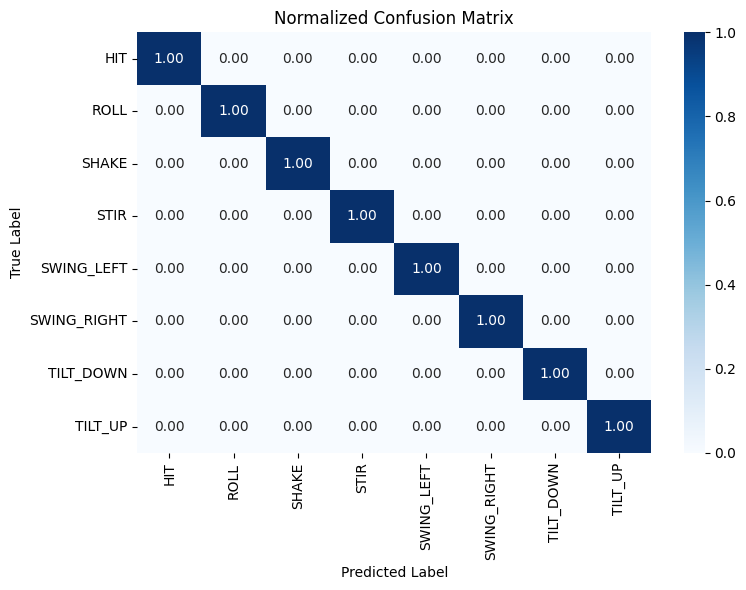

In [234]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

class_names = le.classes_.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,              # use cm for raw counts
    annot=True,                 # write numbers inside cells
    fmt=".2f",                  # 2 decimal places
    cmap="Blues",               # color style
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(f"cmat_{APPROACH}.png")
plt.show()

In [235]:
from sklearn.metrics import classification_report

In [236]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        88
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00       146
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00       152
           5       1.00      1.00      1.00       106
           6       1.00      1.00      1.00        59
           7       1.00      1.00      1.00         5

    accuracy                           1.00       558
   macro avg       1.00      1.00      1.00       558
weighted avg       1.00      1.00      1.00       558



In [237]:
from time import perf_counter

In [238]:
t0 = perf_counter()
a = clf_minirocket.predict(X_train[0:1])
t1 = perf_counter()

In [239]:
print(f"{t1 - t0} seconds taken to perform a single inference!")

0.006149700027890503 seconds taken to perform a single inference!


In [240]:
from skl2onnx import to_onnx

if PACKAGE_USED == 0:
    onx = to_onnx(clf_minirocket, X_train[:1])
    with open(f"clf_{APPROACH}.onnx", "wb") as f:
        f.write(onx.SerializeToString())

In [241]:
from joblib import dump

dump(clf_minirocket, f"clf_{APPROACH}.joblib")

['clf_rf.joblib']

In [242]:
# clf_minirocket.predict(X_train[0:1])

In [243]:
# print(repr(X_train[0:1]))

In [244]:
# print(repr(y_train[0]))